In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="threadpoolctl"
)

In [2]:
USE_HSV = True
USE_RGB = False
USE_GLCM = True

if USE_HSV and USE_RGB:
    raise ValueError("HSV dan RGB tidak boleh digunakan bersamaan.")
if not (USE_HSV or USE_RGB):
    raise ValueError("Pilih minimal HSV atau RGB.")
if not (USE_HSV or USE_RGB or USE_GLCM):
    raise ValueError("Pilih minimal satu jenis fitur.")

feature_parts = []
if USE_HSV:
    feature_parts.append("hsv")
if USE_RGB:
    feature_parts.append("rgb")
if USE_GLCM:
    feature_parts.append("glcm")

FEATURES_NAME = "_".join(feature_parts)

In [3]:
df = pd.read_csv(f"features/{FEATURES_NAME}.csv")

# ==========================================
# [MODIFIKASI BARU]: Daftar 15 Fitur Terbaik
# ==========================================
top_15_features = [
    "correlation_d2_a90",
    "homogeneity_d3_a90",
    "homogeneity_d2_a90",
    "correlation_d1_a90",
    "correlation_d3_a90",
    "correlation_d1_a135",
    "homogeneity_d3_a0",
    "correlation_d2_a135",
    "homogeneity_d2_a0",
    "contrast_d1_a135",
    "homogeneity_d3_a45",
    "contrast_d1_a0",
    "contrast_d3_a0",
    "contrast_d2_a0",
    "contrast_d2_a135"
]

# Ambil HANYA 15 fitur tersebut untuk X, dan label untuk y
x = df[top_15_features]
y = df["label"]

print("Menggunakan 15 Fitur Terbaik:")
print(x.columns.tolist())

Menggunakan 15 Fitur Terbaik:
['correlation_d2_a90', 'homogeneity_d3_a90', 'homogeneity_d2_a90', 'correlation_d1_a90', 'correlation_d3_a90', 'correlation_d1_a135', 'homogeneity_d3_a0', 'correlation_d2_a135', 'homogeneity_d2_a0', 'contrast_d1_a135', 'homogeneity_d3_a45', 'contrast_d1_a0', 'contrast_d3_a0', 'contrast_d2_a0', 'contrast_d2_a135']


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("="*40)
print("Train :", x_train.shape)
print("Test  :", x_test.shape)
print("="*40)

Train : (153, 15)
Test  : (39, 15)


In [5]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Simpan scaler (Tambahkan penanda '_top15' agar tidak menimpa model lama)
os.makedirs("models/knn", exist_ok=True)
joblib.dump(scaler, f"models/knn/{FEATURES_NAME}_top15_scaler.pkl")

['models/knn/hsv_glcm_top15_scaler.pkl']

In [6]:
# K-NEAREST NEIGHBORS (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

# Simpan model KNN
joblib.dump(knn, f"models/knn/{FEATURES_NAME}_top15_model.pkl")

['models/knn/hsv_glcm_top15_model.pkl']

In [7]:
# Prediksi data train & test
y_train_pred = knn.predict(x_train_scaled)
y_test_pred = knn.predict(x_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("KNN Training Accuracy :", train_acc)
print("KNN Testing Accuracy  :", test_acc)
print("\nKNN Classification Report:\n")
print(classification_report(y_test, y_test_pred))

KNN Training Accuracy : 0.8169934640522876
KNN Testing Accuracy  : 0.5384615384615384

KNN Classification Report:

              precision    recall  f1-score   support

        100k       0.75      0.50      0.60         6
         10k       0.25      0.33      0.29         6
         20k       0.43      0.43      0.43         7
          2k       0.50      0.43      0.46         7
         50k       0.75      0.86      0.80         7
          5k       0.67      0.67      0.67         6

    accuracy                           0.54        39
   macro avg       0.56      0.54      0.54        39
weighted avg       0.56      0.54      0.54        39



In [8]:
# Cross Validation KNN
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_scores = cross_val_score(
    knn, 
    x_train_scaled, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("KNN Cross Validation Scores:")
print(f"Scores per fold: {knn_cv_scores}")
print(f"Mean CV Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {knn_cv_scores.std():.4f}")

KNN Cross Validation Scores:
Scores per fold: [0.58064516 0.77419355 0.58064516 0.73333333 0.73333333]
Mean CV Accuracy: 0.6804
Std CV Accuracy: 0.0828


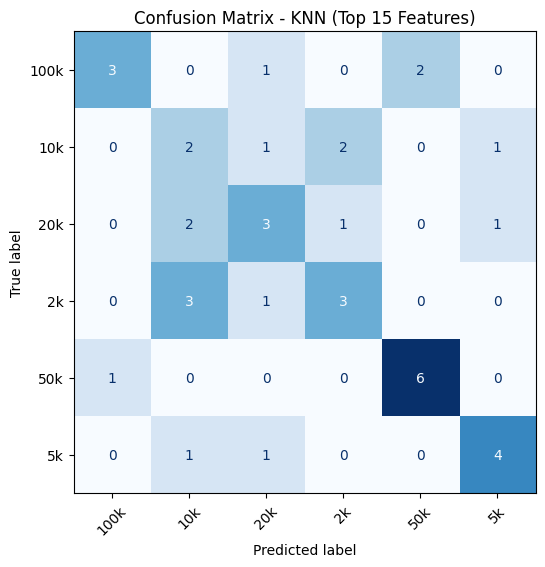

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title("Confusion Matrix - KNN (Top 15 Features)")
plt.show()

In [ ]:
# RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
    
rf.fit(x_train, y_train)

# Simpan model RF
os.makedirs("models/rf", exist_ok=True)
joblib.dump(rf, f"models/rf/{FEATURES_NAME}_top15_model.pkl")

['models/rf/hsv_glcm_top15_model.pkl']

In [11]:
y_train_pred_2 = rf.predict(x_train)
y_test_pred_2 = rf.predict(x_test)

train_acc_rf = accuracy_score(y_train, y_train_pred_2)
test_acc_rf = accuracy_score(y_test, y_test_pred_2)

print("RF Training Accuracy:", train_acc_rf)
print("RF Testing Accuracy :", test_acc_rf)
print("\nRF Classification Report:\n")
print(classification_report(y_test, y_test_pred_2))

RF Training Accuracy: 1.0
RF Testing Accuracy : 0.6153846153846154

RF Classification Report:

              precision    recall  f1-score   support

        100k       0.80      0.67      0.73         6
         10k       0.17      0.17      0.17         6
         20k       0.67      0.57      0.62         7
          2k       0.80      0.57      0.67         7
         50k       0.75      0.86      0.80         7
          5k       0.56      0.83      0.67         6

    accuracy                           0.62        39
   macro avg       0.62      0.61      0.61        39
weighted avg       0.63      0.62      0.61        39



In [12]:
# Cross Validation RF
rf_cv_scores = cross_val_score(
    rf, 
    x_train, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("RF Cross Validation Scores:")
print(f"Scores per fold: {rf_cv_scores}")
print(f"Mean CV Accuracy: {rf_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {rf_cv_scores.std():.4f}")

RF Cross Validation Scores:
Scores per fold: [0.5483871  0.67741935 0.64516129 0.76666667 0.6       ]
Mean CV Accuracy: 0.6475
Std CV Accuracy: 0.0737


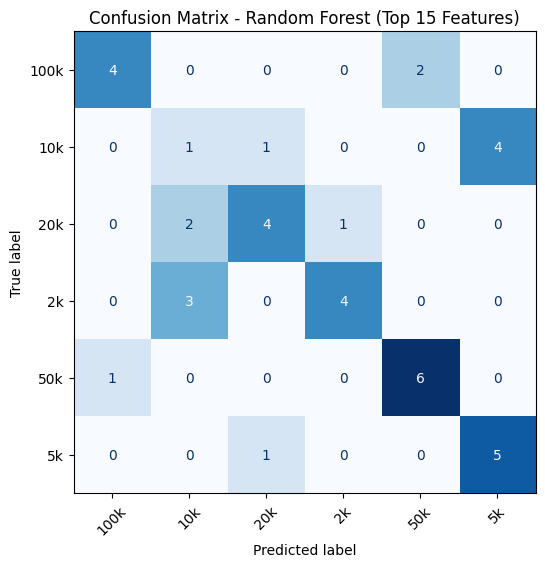

In [13]:
cm_rf = confusion_matrix(y_test, y_test_pred_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title("Confusion Matrix - Random Forest (Top 15 Features)")
plt.show()